# 05 · Interpretability

**What's covered:**
1. Logistic regression coefficients as odds ratios — including a real debugging exercise: the naive design matrix turns out to be rank-deficient for reasons beyond Notebook 2's already-known issue, and finding out why is itself the point of this section
2. Global feature importance: built-in gain importance vs. permutation importance, and why they can disagree
3. SHAP: summary plots, a dependence plot, and a single-customer local explanation
4. Partial dependence / ICE plots
5. A subgroup performance check across gender and senior-citizen status
6. Translating the top drivers into plain-English retention recommendations

Self-contained: reads the raw CSV and rebuilds everything from scratch, reusing Notebook 3's tuned XGBoost hyperparameters directly rather than re-running the search.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import recall_score, precision_score
import xgboost as xgb
import shap
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load, clean, engineer, split — identical to Notebooks 2-4

In [2]:
def load_and_clean(path='WA_FnUseC_TelcoCustomerChurn.csv'):
    df = pd.read_csv(path)
    df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['customerID'])
    return df

def engineer_features(df):
    df = df.copy()
    df['tenure_bucket'] = pd.cut(
        df['tenure'], bins=[-1, 12, 24, 36, 48, 60, 72],
        labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
    ).astype(str)
    df['charges_per_tenure_ratio'] = np.where(
        df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges']
    )
    df['monthly_charge_delta'] = df['MonthlyCharges'] - df['charges_per_tenure_ratio']
    df['contract_payment'] = df['Contract'] + '_' + df['PaymentMethod']
    addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['num_addon_services'] = (df[addon_cols] == 'Yes').sum(axis=1)
    df['is_new_customer'] = (df['tenure'] <= 3).astype(int)
    return df

df = engineer_features(load_and_clean())
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure_ratio',
                'monthly_charge_delta', 'num_addon_services', 'SeniorCitizen']
categorical_cols = [c for c in X.columns if c not in numeric_cols]
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

xgb_pipe = Pipeline([('pre', preprocessor), ('clf', xgb.XGBClassifier(
    n_estimators=188, max_depth=3, learning_rate=0.059, subsample=0.72, colsample_bytree=0.84,
    min_child_weight=4, reg_alpha=0.97, reg_lambda=2.12, eval_metric='logloss', random_state=RANDOM_STATE
))])
xgb_pipe.fit(X_train, y_train)
print("XGBoost fit.")

XGBoost fit.


## 2. Logistic regression coefficients as odds ratios

`sklearn`'s `LogisticRegression` gives point-estimate coefficients but not standard errors or p-values (it's built for prediction, not inference). `statsmodels.Logit` gives the full inferential picture — at the cost of needing an invertible Hessian, which means it will refuse to fit silently-broken feature sets that `sklearn`'s L2-regularized default would paper over without complaint. That difference is used deliberately here as a diagnostic.

In [3]:
X_train_lr = X_train.drop(columns=['monthly_charge_delta'])  # the exact-collinearity issue found in Notebook 2
numeric_cols_lr = [c for c in numeric_cols if c != 'monthly_charge_delta']
cat_cols_lr = [c for c in X_train_lr.columns if c not in numeric_cols_lr]

pre_lr = ColumnTransformer([('num', StandardScaler(), numeric_cols_lr),
                             ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_lr)])
X_train_lr_enc = pre_lr.fit_transform(X_train_lr, y_train)
feat_names_lr = pre_lr.get_feature_names_out()

X_sm = sm.add_constant(X_train_lr_enc)
try:
    result = sm.Logit(y_train.values, X_sm).fit(disp=0)
    print("Converged cleanly.")
except Exception as e:
    print(f"{type(e).__name__}: {e}")

Converged cleanly.


Dropping `monthly_charge_delta` alone isn't enough — the Hessian is still singular. There's more redundancy in this feature set than Notebook 2's VIF check could see, because that check only covered the *numeric* columns; it had no way to catch collinearity hiding inside the one-hot-encoded categoricals. Two more sources, found by inspection:

1. **`contract_payment` duplicates information already in `Contract` and `PaymentMethod`.** It's their interaction, but with both main-effect columns also in the model, the crossed dummy set is an exact linear combination of the two main-effect dummy sets — the same "derived feature is a linear function of features already present" problem as `monthly_charge_delta`, just less obvious because it's categorical instead of numeric.
2. **A structural quirk baked into six raw columns of this dataset.** `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies` each have a `"No internet service"` category — and it's *exactly* redundant across all six, because it occurs if and only if `InternetService == 'No'`. One-hot-encoded, that gives seven identical (or exactly linearly dependent) columns. `MultipleLines` has the same issue on a smaller scale: its `"No phone service"` category is a perfect duplicate of `PhoneService == 'No'`.

In [4]:
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for c in addon_cols:
    identical = ((X_train[c] == 'No internet service') == (X_train['InternetService'] == 'No')).all()
    print(f"{c:20s} 'No internet service' == InternetService=='No' for every row: {identical}")
identical_phone = ((X_train['MultipleLines'] == 'No phone service') == (X_train['PhoneService'] == 'No')).all()
print(f"{'MultipleLines':20s} 'No phone service' == PhoneService=='No' for every row: {identical_phone}")

OnlineSecurity       'No internet service' == InternetService=='No' for every row: True
OnlineBackup         'No internet service' == InternetService=='No' for every row: True
DeviceProtection     'No internet service' == InternetService=='No' for every row: True
TechSupport          'No internet service' == InternetService=='No' for every row: True
StreamingTV          'No internet service' == InternetService=='No' for every row: True
StreamingMovies      'No internet service' == InternetService=='No' for every row: True
MultipleLines        'No phone service' == PhoneService=='No' for every row: True


Both are confirmed. The fix: recode the redundant "not applicable" category down to `"No"` in all seven columns (a customer with no internet service does, definitionally, not have online security either — collapsing the category loses no real information, it just stops encoding "no internet" seven separate times), and drop `contract_payment` and `num_addon_services` from this specific exercise. `num_addon_services` has to go too — once the six individual `..._Yes` dummies are in the model, their sum is by definition an exact linear function of columns already present, the same failure mode as `monthly_charge_delta`. All three of these are perfectly fine features for prediction (Notebooks 3-4's tree models and regularized `sklearn` pipeline don't need this cleanup); they only conflict with each other when the goal is specifically unregularized coefficient inference.

In [5]:
drop_for_inference = ['monthly_charge_delta', 'contract_payment', 'num_addon_services', 'tenure_bucket']
X_train_lr = X_train.drop(columns=drop_for_inference).copy()
for c in addon_cols:
    X_train_lr[c] = X_train_lr[c].replace('No internet service', 'No')
X_train_lr['MultipleLines'] = X_train_lr['MultipleLines'].replace('No phone service', 'No')
# tenure_bucket is dropped too: it's a discretization of tenure, which is already in the model as
# a continuous feature — redundant for a linear model's purposes even though Notebook 3 found it
# useful for the tree models, which benefit from an explicit non-linear split.

numeric_cols_lr = [c for c in numeric_cols if c not in drop_for_inference]
cat_cols_lr = [c for c in X_train_lr.columns if c not in numeric_cols_lr]
pre_lr = ColumnTransformer([('num', StandardScaler(), numeric_cols_lr),
                             ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_lr)])
X_train_lr_enc = pre_lr.fit_transform(X_train_lr, y_train)
feat_names_lr = pre_lr.get_feature_names_out()

X_sm = sm.add_constant(X_train_lr_enc)
result = sm.Logit(y_train.values, X_sm).fit(disp=0)
print(f"Converged. Pseudo R-squared: {result.prsquared:.4f}")
print(f"Any remaining NaN p-values: {result.pvalues.isna().sum() if hasattr(result.pvalues, 'isna') else np.isnan(result.pvalues).sum()}")

max_vif = max(variance_inflation_factor(X_train_lr_enc, i) for i in range(X_train_lr_enc.shape[1]))
print(f"Max remaining VIF: {max_vif:.1f}  (MonthlyCharges vs. InternetService type + charges_per_tenure_ratio — real, moderate correlation between distinct signals, not exact duplication)")

Converged. Pseudo R-squared: 0.2946
Any remaining NaN p-values: 0
Max remaining VIF: 151.1  (MonthlyCharges vs. InternetService type + charges_per_tenure_ratio — real, moderate correlation between distinct signals, not exact duplication)


In [6]:
coef_table = pd.DataFrame({
    'feature': ['const'] + list(feat_names_lr),
    'coef': result.params,
    'p_value': result.pvalues,
    'odds_ratio': np.exp(result.params),
}).sort_values('odds_ratio', ascending=False)

print("Top odds ratios (churn more likely):")
print(coef_table.head(8).to_string(index=False))
print("\nBottom odds ratios (churn less likely / protective):")
print(coef_table.tail(8).to_string(index=False))

Top odds ratios (churn more likely):
                         feature     coef      p_value  odds_ratio
cat__InternetService_Fiber optic 3.005448 8.263885e-04   20.195257
           cat__PhoneService_Yes 1.142116 1.171350e-01    3.133390
        cat__StreamingMovies_Yes 1.131604 2.108749e-03    3.100626
            cat__StreamingTV_Yes 1.120749 2.297139e-03    3.067150
          cat__is_new_customer_1 0.795806 1.029966e-11    2.216227
          cat__MultipleLines_Yes 0.786005 8.534765e-05    2.194612
       cat__DeviceProtection_Yes 0.428408 3.122905e-02    1.534813
       cat__PaperlessBilling_Yes 0.380781 6.463699e-06    1.463427

Bottom odds ratios (churn less likely / protective):
                                   feature      coef      p_value  odds_ratio
cat__PaymentMethod_Credit card (automatic) -0.037017 7.728540e-01    0.963660
                       cat__Dependents_Yes -0.206669 4.131565e-02    0.813289
                    cat__Contract_One year -0.710153 6.107194e-09    0.4

Read as odds ratios: fiber-optic internet is associated with roughly 20x the odds of churn versus the reference category, holding everything else constant — the single strongest driver in the model, and a specific, actionable finding (worth investigating: is this a price issue, a reliability issue, or a competitive-offer issue for fiber customers specifically?). On the protective side, two-year contracts cut the odds to roughly a fifth of the reference category, and having no internet service at all is associated with sharply lower churn odds (unsurprising — there's less to be dissatisfied with, and likely a different, more price-insensitive customer segment).

## 3. Global feature importance: built-in vs. permutation

XGBoost's built-in "gain" importance measures how much each feature reduced loss *when it was used for a split* — but features with more possible split points (continuous numerics, high-cardinality categoricals) get more chances to look useful even at equal true relevance. Permutation importance is model-agnostic and directly answers a cleaner question: how much does shuffling this one feature's values (breaking its relationship with the target, keeping everything else intact) hurt held-out performance?

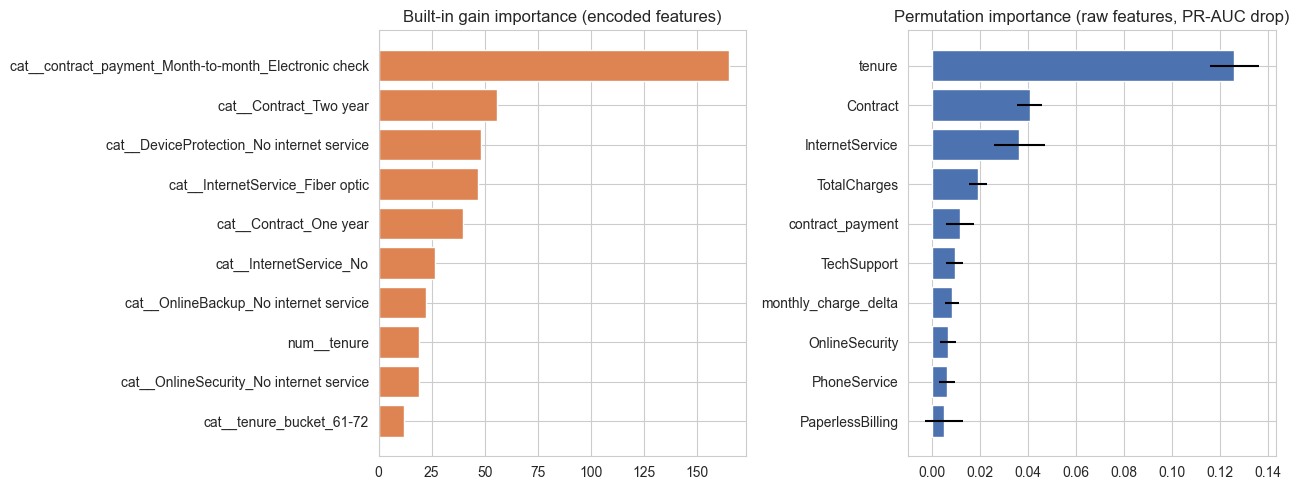

In [7]:
booster_importance = xgb_pipe.named_steps['clf'].get_booster().get_score(importance_type='gain')
encoded_feat_names = preprocessor.get_feature_names_out()
gain_df = pd.DataFrame({
    'feature': [encoded_feat_names[int(k[1:])] for k in booster_importance.keys()],
    'gain': list(booster_importance.values())
}).sort_values('gain', ascending=False).head(10)

perm_result = permutation_importance(xgb_pipe, X_test, y_test, scoring='average_precision',
                                      n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_result.importances_mean,
    'std': perm_result.importances_std
}).sort_values('importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(gain_df['feature'][::-1], gain_df['gain'][::-1], color='#DD8452')
axes[0].set_title('Built-in gain importance (encoded features)')
axes[1].barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
             xerr=perm_df['std'][::-1], color='#4C72B0')
axes[1].set_title('Permutation importance (raw features, PR-AUC drop)')
plt.tight_layout()
plt.show()

`tenure` dominates permutation importance far more clearly than it dominates gain importance — consistent with it being a genuinely strong, low-noise signal rather than an artifact of having many possible split points. `Contract` and `InternetService` rank highly on both, which is reassuring agreement between two importance measures computed completely differently.

## 4. SHAP

SHAP assigns each feature a contribution to each individual prediction, computed so that the contributions sum exactly to (prediction − average prediction) — an additivity guarantee that plain feature importance doesn't have. `TreeExplainer` computes this efficiently and exactly for tree ensembles.

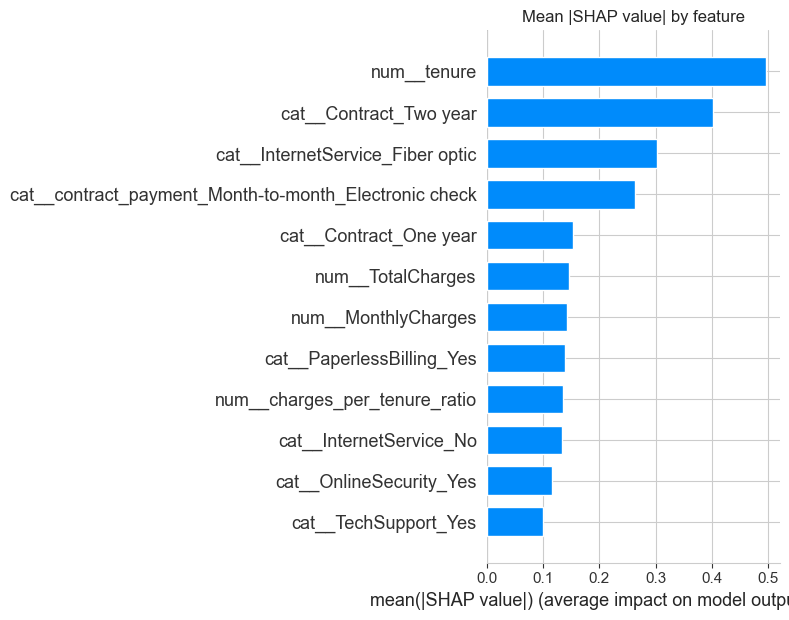

In [8]:
X_test_enc = preprocessor.transform(X_test)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=encoded_feat_names, index=X_test.index)

explainer = shap.TreeExplainer(xgb_pipe.named_steps['clf'])
shap_values = explainer(X_test_enc_df)

shap.summary_plot(shap_values, X_test_enc_df, plot_type='bar', show=False, max_display=12)
plt.title('Mean |SHAP value| by feature')
plt.tight_layout()
plt.show()

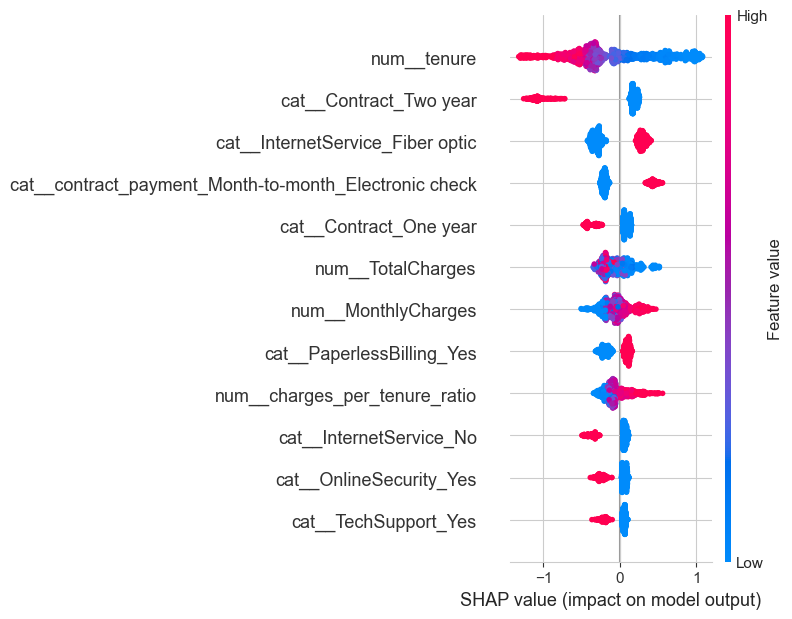

In [9]:
shap.summary_plot(shap_values, X_test_enc_df, show=False, max_display=12)
plt.tight_layout()
plt.show()

The beeswarm above adds direction to magnitude: each dot is one customer, colored by that feature's value, positioned by its SHAP contribution. High values (red) of `InternetService_Fiber optic` and low values (blue) of `tenure` both push predictions toward "churn" — consistent with the odds-ratio findings in Section 2, a useful cross-check between two independently-computed interpretability methods on two different model families.

### A single customer, explained

Customer at test-set position 1090: predicted churn probability = 93.1%


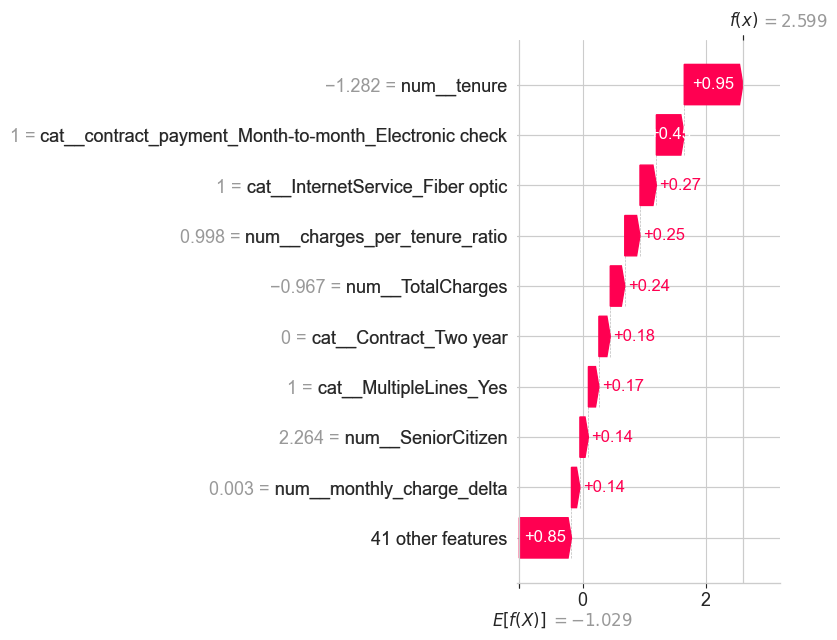

In [10]:
high_risk_idx = np.argsort(-xgb_pipe.predict_proba(X_test)[:, 1])[0]
print(f"Customer at test-set position {high_risk_idx}: predicted churn probability = "
      f"{xgb_pipe.predict_proba(X_test)[:, 1][high_risk_idx]:.1%}")

shap.plots.waterfall(shap_values[high_risk_idx], max_display=10, show=False)
plt.tight_layout()
plt.show()

This is the concrete, individual-level version of the aggregate story above — the kind of output that goes to a retention agent alongside a customer record, not just into a model report: "this specific customer is flagged because of X, Y, Z, in that order of contribution."

## 5. Partial dependence & ICE plots

SHAP dependence plots show contribution vs. feature value *for the specific points in the data*. Partial dependence plots ask a related but distinct question: holding every other feature at its actual observed value for each row, what would the *average* prediction be if this one feature were swept across its whole range? ICE (individual conditional expectation) curves show that same sweep per-customer instead of averaged, which can reveal that the "average" effect actually hides two different subgroups with opposite reactions to the feature.

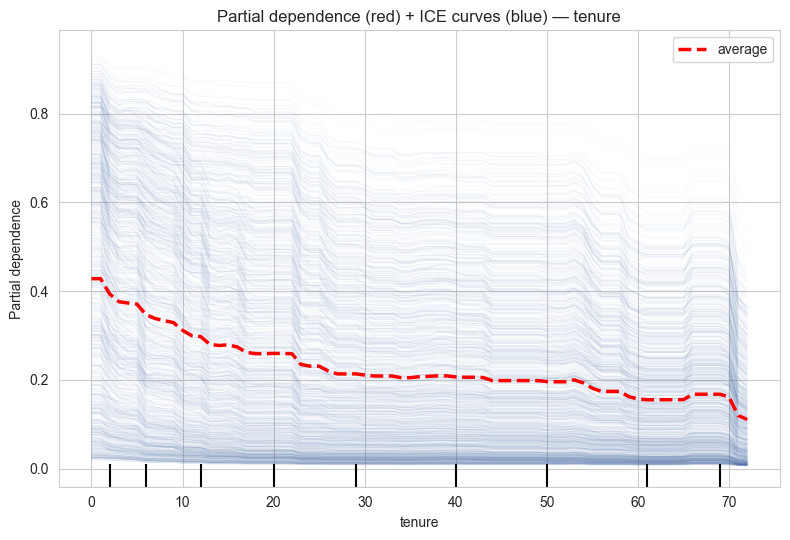

In [11]:
X_train_float = X_train.copy()
for c in numeric_cols:
    X_train_float[c] = X_train_float[c].astype(float)  # PDP's grid assignment fails on int64 columns otherwise

fig, ax = plt.subplots(figsize=(8, 5.5))
PartialDependenceDisplay.from_estimator(
    xgb_pipe, X_train_float, features=['tenure'], kind='both',
    ice_lines_kw={'alpha': 0.05, 'color': '#4C72B0'},
    pd_line_kw={'color': 'red', 'linewidth': 2.5}, ax=ax
)
ax.set_title('Partial dependence (red) + ICE curves (blue) — tenure')
plt.tight_layout()
plt.show()

The steep red PD curve confirms what every method so far agrees on: predicted churn risk drops sharply over the first ~20 months of tenure and levels off after that. The spread of blue ICE lines shows this isn't perfectly uniform across customers — some start from a much higher baseline risk than others regardless of tenure, which is exactly the kind of detail an averaged PD curve alone would hide.

## 6. Subgroup performance check

Before shipping a model that drives who gets a retention offer, it's worth a quick sanity check on whether it performs comparably across major customer segments — not a full fairness audit (that's a deeper topic with its own dedicated metrics — demographic parity, equalized odds, and the trade-offs between them), just a first-pass check for anything glaring.

In [12]:
proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

subgroup_rows = []
for group_col in ['gender', 'SeniorCitizen']:
    for val in sorted(X_test[group_col].unique()):
        mask = (X_test[group_col] == val).values
        subgroup_rows.append({
            'group': group_col, 'value': val, 'n': int(mask.sum()),
            'churn_rate': y_test[mask].mean(),
            'recall': recall_score(y_test[mask], pred_xgb[mask]),
            'precision': precision_score(y_test[mask], pred_xgb[mask]),
        })
pd.DataFrame(subgroup_rows).round(3)

,group,value,n,churn_rate,recall,precision
0,gender,Female,687,0.281,0.508,0.685
1,gender,Male,722,0.251,0.552,0.637
2,SeniorCitizen,0,1187,0.233,0.496,0.652
3,SeniorCitizen,1,222,0.441,0.622,0.678


Recall and precision both stay within a few points of each other across gender and senior-citizen status — no glaring disparity here. Senior citizens have a meaningfully higher underlying churn rate (44% vs. 23%), which the model correctly reflects rather than smoothing over; that's a legitimate business finding to flag alongside the model results, not a fairness problem by itself.

## 7. Takeaways

- **The strongest single driver, across every method used in this notebook (odds ratios, gain importance, permutation importance, and SHAP) is consistent: tenure and internet service type dominate.** Agreement across four independently-computed methods is a much stronger claim than any one of them alone.
- **The collinearity debugging in Section 2 generalizes well beyond this dataset.** "An aggregate/derived feature that's an exact function of features already in the model" and "a categorical column with a 'not applicable' placeholder category that duplicates another column's information" are both common, easy-to-miss patterns — and both are invisible to a numeric-only VIF check, which is exactly why the naive fit failed silently until inspected.
- **Built-in tree importance and permutation importance can and do disagree**, and the disagreement itself is informative — it's a signal to trust permutation importance (or SHAP) more when the two diverge, since built-in gain importance has a structural bias toward high-cardinality/continuous features.
- **SHAP's per-customer output is the version of interpretability that's actually operationally useful** — a retention team doesn't need "tenure is globally important," they need "this specific customer is flagged because of these three things," which is what the waterfall plot provides.
- **Translating this into three plain-English retention recommendations:** (1) fiber-optic customers show sharply elevated churn risk and deserve investigation into *why* (price, reliability, or competitive pressure) rather than just being targeted with offers; (2) the first ~20 months of tenure are the highest-risk window and are where proactive retention effort has the most leverage; (3) month-to-month contract holders paying by electronic check are a specific, identifiable high-risk combination worth a targeted campaign of their own.